In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [2]:
from google.colab import files
uploaded=files.upload()
filename=next(iter(uploaded))
df=pd.read_excel(filename,sheet_name="Data")

Saving EX6_6_3_data.xlsx to EX6_6_3_data.xlsx


In [3]:
X=df.drop('Company',axis=1)
y=df['Company']

In [4]:
encoder=LabelEncoder()
y_encoded=encoder.fit_transform(y)
X_encoded=pd.get_dummies(X,drop_first=True)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y_encoded,test_size=0.2,random_state=42)

In [6]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [7]:
y_pred=model.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_pred)
print(f"Model Accuracy on Test Set: {accuracy*100:.2f}%")

Model Accuracy on Test Set: 33.33%


In [8]:
sample=X_test.iloc[[0]]
prediction=model.predict(sample)
predicted_company=encoder.inverse_transform(prediction)[0]
print(f"Predicted Product (Brand) for this customer: {predicted_company}")

Predicted Product (Brand) for this customer: Ford


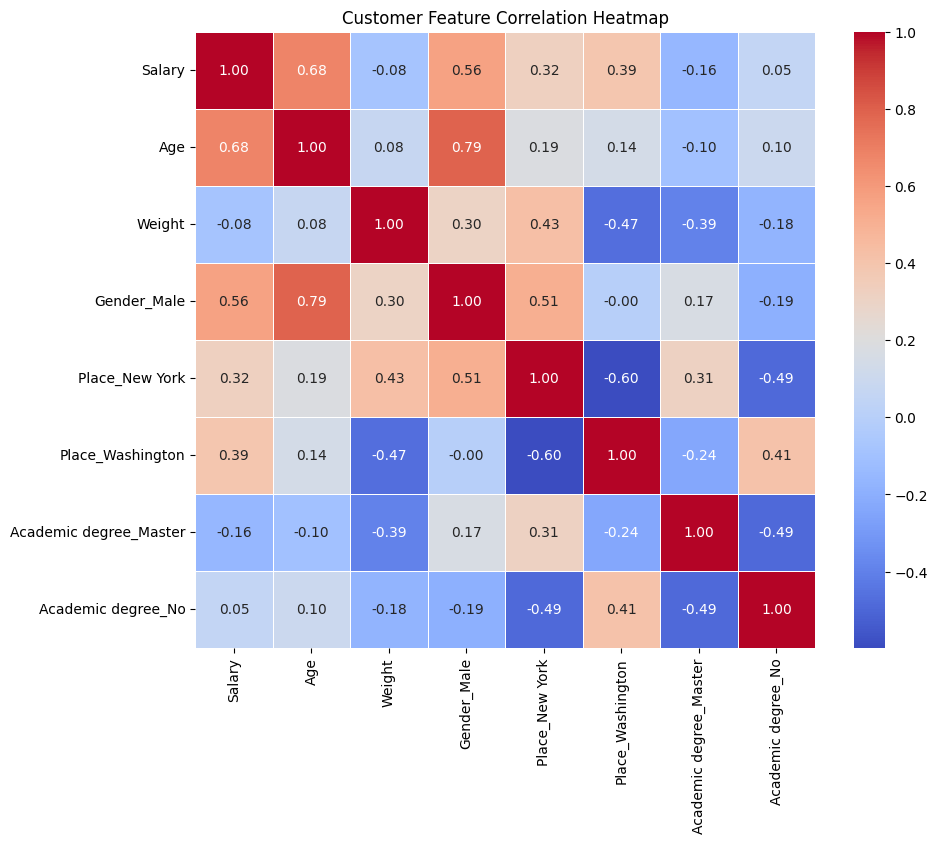

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
correlation_matrix=X_encoded.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Customer Feature Correlation Heatmap')
plt.show()